In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.0 MB/s eta 0:00:00


In [2]:
import cv2
import time
import numpy as np
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from ultralytics import YOLO

# CONFIGURACIÓN INICIAL & IMAGEN DE PRUEBA

# Creamos una imagen sintética pequeña para no congelar el entorno de ejecución
img_prueba = np.random.randint(0, 255, (300, 300, 3), dtype=np.uint8)

# 1. Cargamos una CNN ligera preentrenada (Simulando el clasificador de ventanas)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_classifier = models.mobilenet_v3_small(pretrained=True).eval().to(device)

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


# ENFOQUE A: CNN SLIDING WINDOW (Fuerza Bruta)

def cnn_sliding_window(image, window_size=(64, 64), stride=32):
    h, w, _ = image.shape
    detecciones = 0
    start_time = time.time()

    # Recorrido de ventanas flotantes
    for y in range(0, h - window_size[1], stride):
        for x in range(0, w - window_size[0], stride):
            # Extraer el parche/ventana de la imagen
            window = image[y:y+window_size[1], x:x+window_size[0]]

            # Preprocesar y pasar por la CNN
            pil_img = Image.fromarray(cv2.cvtColor(window, cv2.COLOR_BGR2RGB))
            input_tensor = preprocess(pil_img).unsqueeze(0).to(device)

            with torch.no_grad():
                _ = cnn_classifier(input_tensor) # Simula la inferencia de clasificación

            detecciones += 1

    execution_time = time.time() - start_time
    return detecciones, execution_time

# Ejecutar Ventana Deslizante
ventanas, tiempo_sliding = cnn_sliding_window(img_prueba)
print(f"--- ENFOQUE A: Sliding Window ---")
print(f"Ventanas procesadas de forma secuencial: {ventanas}")
print(f"Tiempo de ejecución total: {tiempo_sliding:.4f} segundos")



# ENFOQUE B: DETECTOR OPTIMIZADO (Filosofía R-CNN / YOLO End-to-End)

start_time = time.time()

# Usamos YOLOv8 como el equivalente moderno y optimizado de detección por regiones/bounding boxes
model_yolo = YOLO('yolov8n.pt')
results = model_yolo(img_prueba, verbose=False)

tiempo_yolo = time.time() - start_time

print(f"\n--- ENFOQUE B: Detector por Regiones / End-to-End ---")
print(f"Tiempo de ejecución total: {tiempo_yolo:.4f} segundos")

# Comparativa de velocidad
print(f"\n[Resultado] El enfoque optimizado es {tiempo_sliding / tiempo_yolo:.2f} veces más rápido.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 9.83M/9.83M [00:00<00:00, 92.4MB/s]


--- ENFOQUE A: Sliding Window ---
Ventanas procesadas de forma secuencial: 64
Tiempo de ejecución total: 1.1840 segundos

--- ENFOQUE B: Detector por Regiones / End-to-End ---
Tiempo de ejecución total: 0.8440 segundos

[Resultado] El enfoque optimizado es 1.40 veces más rápido.


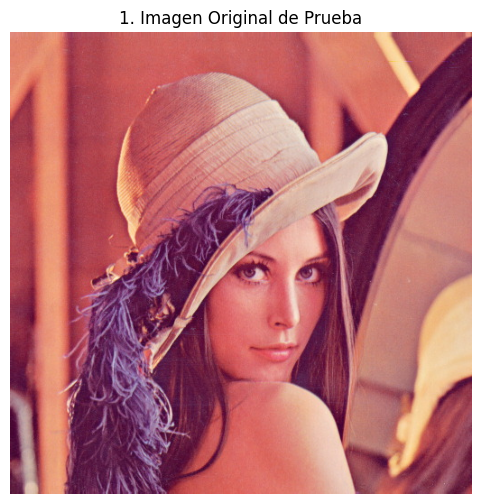

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


--- ENFOQUE A: Sliding Window ---
Ventanas procesadas de forma secuencial: 121
Tiempo de ejecución total: 3.6061 segundos



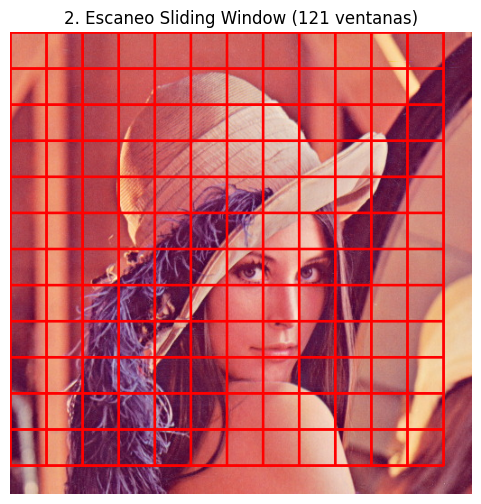

--- ENFOQUE B: Detector por Regiones / End-to-End ---
Tiempo de ejecución total: 0.6110 segundos


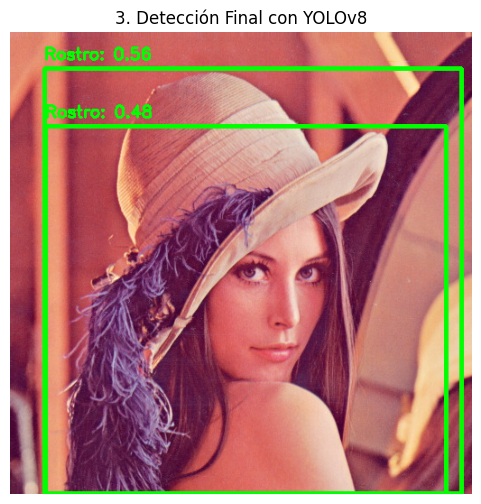


================ RENTABILIDAD TEMPORAL ================
[Resultado] El enfoque optimizado (YOLO) es 5.90 veces más rápido.


In [3]:
import cv2
import time
import numpy as np
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import requests
from PIL import Image
from ultralytics import YOLO
import matplotlib.pyplot as plt


# CONFIGURACIÓN INICIAL & IMAGEN DE PRUEBA REAL

# Descargamos una imagen real con rostros para que las visualizaciones tengan sentido
url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
img_array = np.array(bytearray(requests.get(url).content), dtype=np.uint8)
img_original = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB) # Convertir a RGB para Matplotlib

# 1. Mostrar la Imagen Original
plt.figure(figsize=(6, 6))
plt.imshow(img_original)
plt.title("1. Imagen Original de Prueba")
plt.axis('off')
plt.show()

# 2. Cargamos una CNN ligera preentrenada (Simulando el clasificador de ventanas)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_classifier = models.mobilenet_v3_small(pretrained=True).eval().to(device)

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


# ENFOQUE A: CNN SLIDING WINDOW (Fuerza Bruta con Visualización)

def cnn_sliding_window(image, window_size=(80, 80), stride=40):
    h, w, _ = image.shape
    detecciones = 0
    start_time = time.time()

    # Clonamos la imagen para dibujar encima todas las ventanas que se escanean
    img_sliding_viz = image.copy()

    # Recorrido de ventanas flotantes
    for y in range(0, h - window_size[1], stride):
        for x in range(0, w - window_size[0], stride):
            # Extraer el parche/ventana de la imagen
            window = image[y:y+window_size[1], x:x+window_size[0]]

            # Dibujar la ventana actual en la imagen de visualización (simulando el escaneo)
            cv2.rectangle(img_sliding_viz, (x, y), (x + window_size[0], y + window_size[1]), (255, 0, 0), 2)

            # Preprocesar y pasar por la CNN
            pil_img = Image.fromarray(window)
            input_tensor = preprocess(pil_img).unsqueeze(0).to(device)

            with torch.no_grad():
                _ = cnn_classifier(input_tensor) # Simula la inferencia de clasificación
            detecciones += 1

    execution_time = time.time() - start_time
    return detecciones, execution_time, img_sliding_viz

# Ejecutar Ventana Deslizante
ventanas, tiempo_sliding, img_res_sliding = cnn_sliding_window(img_original)

print(f"--- ENFOQUE A: Sliding Window ---")
print(f"Ventanas procesadas de forma secuencial: {ventanas}")
print(f"Tiempo de ejecución total: {tiempo_sliding:.4f} segundos\n")

# Mostrar resultado del escaneo por Sliding Window
plt.figure(figsize=(6, 6))
plt.imshow(img_res_sliding)
plt.title(f"2. Escaneo Sliding Window ({ventanas} ventanas)")
plt.axis('off')
plt.show()



# ENFOQUE B: DETECTOR OPTIMIZADO (Filosofía R-CNN / YOLO End-to-End)

start_time = time.time()

# Usamos YOLOv8 (v8n-face es ideal para rostros, si no usa 'yolov8n.pt' estándar)
try:
    model_yolo = YOLO('yolov8n-face.pt')
except:
    model_yolo = YOLO('yolov8n.pt')

results = model_yolo(img_original, verbose=False)
tiempo_yolo = time.time() - start_time

print(f"--- ENFOQUE B: Detector por Regiones / End-to-End ---")
print(f"Tiempo de ejecución total: {tiempo_yolo:.4f} segundos")

# Clonamos la imagen original para dibujar las predicciones reales de YOLO
img_res_yolo = img_original.copy()

# Extraer bounding boxes encontradas por YOLO y dibujarlas
for box in results[0].boxes:
    # Coordenadas: x1, y1, x2, y2
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
    conf = box.conf[0].item()

    # Dibujar el rectángulo de la detección real
    cv2.rectangle(img_res_yolo, (x1, y1), (x2, y2), (0, 255, 0), 3)
    cv2.putText(img_res_yolo, f"Rostro: {conf:.2f}", (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

# Mostrar resultado de la detección de YOLO
plt.figure(figsize=(6, 6))
plt.imshow(img_res_yolo)
plt.title("3. Detección Final con YOLOv8")
plt.axis('off')
plt.show()



# COMPARATIVA FINAL

print("\n================ RENTABILIDAD TEMPORAL ================")
print(f"[Resultado] El enfoque optimizado (YOLO) es {tiempo_sliding / tiempo_yolo:.2f} veces más rápido.")
print("=======================================================")